## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')#completa el código

In [3]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [5]:
# Examinar la estructura de traffic
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo  object
- Deben ser cambiadas a tipo datetime

In [6]:
# Examinar la estructura de eco
eco.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, 'PM2.5','Population(M)' son tipo object
- Deben ser cambiadas a float

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:

#Estandarizar los nombres de las columnas de traffic
traffic.columns = (
    traffic.columns.str.lower()
)

traffic=traffic.rename(columns={'country':'country', 
                                'city':'city', 
                                'updatetimeutc':'update_time_utc', 
                                'jamsdelay':'jams_delay', 
                                'trafficindexlive':'traffic_index_live',
                                'jamslengthinkms':'jams_length_in_kms', 
                                'jamscount':'jams_count', 
                                'trafficindexweekago':'traffic_index_week_ago',
                                'updatetimeutcweekago':'update_time_utc_week_ago', 
                                'traveltimeliveper10kmsmins':'travel_time_live_per_10kms_mins',
                                'traveltimehistoricper10kmsmins':'travel_time_historic_per_10kms_mins', 
                                'minsdelay':'mins_delay'})

# Verificar
print(traffic.columns)


# Verificar el resultado



Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')


In [8]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco.columns=(eco.columns.str.replace(' ','_').str.lower())


eco=eco.rename(columns={'year':'year', 
                        'city':'city',
                        'country':'country', 
                        'city_gdp/capita':'city_gdp_capita',
                        'unemployment_%':'unemployment_pct',
                        'pm2.5_(μg/m³)':'pm25_μg/m³', 
                        'population_(m)':'population_m'})


# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25_μg/m³', 'population_m'],
      dtype='object')

In [9]:
eco=eco.rename(columns={'year':'year', 
                        'city':'city',
                        'country':'country', 
                        'city-gdp_capita':'city_gdp_capita',
                        'unemployment_pct':'unemployment_pct',
                        'pm25_μg/m³':'pm25_μg/m³', 
                        'population':'population_m'})
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25_μg/m³', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [10]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])#tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])#tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [11]:



# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = (eco['city_gdp_capita'].astype(str)
                        .str.replace('.', '')
                        .str.replace(',', '.')
                        .astype(float))

eco['unemployment_pct'] = (eco['unemployment_pct'].astype(str)
                        .str.replace('.', '')
                        .str.replace(',', '.')
                        .str.replace('%','')
                        .astype(float))

eco['population_m'] = (eco['population_m'].astype(str)
                        .str.replace('.', '')
                        .str.replace(',', '.')
                        .astype(float))

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25_μg/m³        30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25_μg/m³,population_m,population
0,2023,buenos-aires,Argentina,15782.0,62.0,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,91.0,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,98.0,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [12]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = pd.to_datetime(traffic['update_time_utc']).dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [13]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25_μg/m³,population_m,population
15,2024,buenos-aires,Argentina,18117.0,72.0,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,85.0,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,92.0,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,78.0,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,124.0,"15,20",3.9,3900000.0


In [29]:
eco['year'].unique()

array([2023, 2024])

In [30]:
eco_2024.shape

(15, 8)

array([2023, 2024])


---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [14]:
# Calcular los  promedios de trafico por ciudad, país y año

traffic_city_year_2024 = traffic_2024.groupby(['city','country','year'])[['jams_delay', 
                                                                        'traffic_index_live', 
                                                                        'jams_length_in_kms', 
                                                                        'jams_count', 
                                                                        'mins_delay',
                                                                        'travel_time_live_per_10kms_mins',
                                                                        'travel_time_historic_per_10kms_mins']]\
                                   .agg(["mean"]).reset_index() 
# tu código aqui

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
,,,,mean,mean,mean,mean,mean,mean,mean
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [15]:
traffic_city_year_2024.sort_values(("jams_delay","mean"), ascending=False) # tu código aquí

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
,,,,mean,mean,mean,mean,mean,mean,mean
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [16]:
#la ciudad con mayor jams_delay promedio es mexico-city

In [31]:
sorted(traffic_2024_small['city'].unique())

['a-coruna',
 'aachen',
 'aarhus',
 'abu-dhabi',
 'adana',
 'adelaide',
 'akron',
 'al-ain',
 'albany',
 'albuquerque',
 'alicante',
 'allentown',
 'almere',
 'amersfoort',
 'amsterdam',
 'ankara',
 'antalya',
 'antwerp',
 'apeldoorn',
 'arnhem',
 'athens',
 'atlanta',
 'auckland',
 'augsburg',
 'austin',
 'avignon',
 'bakersfield',
 'baltimore',
 'bangalore',
 'bangkok',
 'barcelona',
 'bari',
 'basel',
 'baton-rouge',
 'belfast',
 'belo-horizonte',
 'bergen',
 'berlin',
 'bern',
 'bialystok',
 'bielefeld',
 'bielsko-biala',
 'bilbao',
 'birmingham',
 'bloemfontein',
 'bogota',
 'boise',
 'bologna',
 'bonn',
 'bordeaux',
 'boston',
 'bournemouth',
 'braga',
 'brasilia',
 'bratislava',
 'breda',
 'bremen',
 'brescia',
 'brest',
 'brighton-and-hove',
 'brisbane',
 'bristol',
 'brno',
 'bruges',
 'brussels',
 'bucharest',
 'budapest',
 'buenos-aires',
 'buffalo',
 'bursa',
 'bydgoszcz',
 'cadiz',
 'cagliari',
 'cairo',
 'calgary',
 'canberra',
 'cape-coral-fort-myers',
 'cape-town',
 'ca

In [32]:
sorted(eco_2024_small['city'].unique())

['belo-horizonte',
 'bogota',
 'brasilia',
 'buenos-aires',
 'curitiba',
 'fortaleza',
 'lima',
 'mexico-city',
 'montevideo',
 'porto-alegre',
 'recife',
 'rio-de-janeiro',
 'salvador',
 'santiago',
 'sao-paulo']

In [33]:
set(eco_2024_small['city']) & set(traffic_2024_small['city'])

{'belo-horizonte',
 'bogota',
 'brasilia',
 'buenos-aires',
 'curitiba',
 'fortaleza',
 'lima',
 'mexico-city',
 'montevideo',
 'porto-alegre',
 'recife',
 'rio-de-janeiro',
 'salvador',
 'santiago',
 'sao-paulo'}

In [17]:
traffic_city_year_2024.columns

MultiIndex([(                               'city',     ''),
            (                            'country',     ''),
            (                               'year',     ''),
            (                         'jams_delay', 'mean'),
            (                 'traffic_index_live', 'mean'),
            (                 'jams_length_in_kms', 'mean'),
            (                         'jams_count', 'mean'),
            (                         'mins_delay', 'mean'),
            (    'travel_time_live_per_10kms_mins', 'mean'),
            ('travel_time_historic_per_10kms_mins', 'mean')],
           )

In [18]:
traffic_city_year_2024.columns = ['_'.join(col).strip('_') for col in traffic_city_year_2024.columns]
traffic_city_year_2024.columns

Index(['city', 'country', 'year', 'jams_delay_mean', 'traffic_index_live_mean',
       'jams_length_in_kms_mean', 'jams_count_mean', 'mins_delay_mean',
       'travel_time_live_per_10kms_mins_mean',
       'travel_time_historic_per_10kms_mins_mean'],
      dtype='object')

,city,country,year,jams_delay_mean,traffic_index_live_mean,jams_length_in_kms_mean,jams_count_mean,mins_delay_mean,travel_time_live_per_10kms_mins_mean,travel_time_historic_per_10kms_mins_mean,city_gdp_capita,unemployment_pct,pm25_μg/m³,population_m


In [47]:
traffic_2024_small[traffic_2024_small['city'] == 'mexico-city'][['city', 'country', 'year']]

,city,country,year
221,mexico-city,MEX,2024


In [48]:
eco_2024_small[eco_2024_small['city'] == 'mexico-city'][['city', 'country', 'year']]


,city,country,year
27,mexico-city,Mexico,2024


In [49]:
traffic_2024_small['country'].unique()

array(['ESP', 'DEU', 'DNK', 'ARE', 'TUR', 'AUS', 'USA', 'NLD', 'BEL',
       'GRC', 'NZL', 'FRA', 'IND', 'THA', 'ITA', 'CHE', 'GBR', 'BRA',
       'NOR', 'POL', 'ZAF', 'COL', 'PRT', 'SVK', 'CZE', 'ROU', 'HUN',
       'ARG', 'EGY', 'CAN', 'IRL', 'SAU', 'QAT', 'SWE', 'AUT', 'FIN',
       'HKG', 'IDN', 'TWN', 'JPN', 'MYS', 'KWT', 'PER', 'SVN', 'LUX',
       'PHL', 'MEX', 'URY', 'ISL', 'LVA', 'CHL', 'SGP', 'BGR', 'EST',
       'LTU'], dtype=object)

In [50]:
eco_2024_small['country'].unique()

array(['Argentina', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'Peru',
       'Uruguay'], dtype=object)

In [63]:
# Revisa si hay espacios extra
traffic_2024_small['country'].apply(lambda x: repr(x)).unique()

array(["'ESP'", "'DEU'", "'DNK'", "'ARE'", "'TUR'", "'AUS'", "'USA'",
       "'NLD'", "'BEL'", "'GRC'", "'NZL'", "'FRA'", "'IND'", "'THA'",
       "'ITA'", "'CHE'", "'GBR'", "'BRA'", "'NOR'", "'POL'", "'ZAF'",
       "'COL'", "'PRT'", "'SVK'", "'CZE'", "'ROU'", "'HUN'", "'ARG'",
       "'EGY'", "'CAN'", "'IRL'", "'SAU'", "'QAT'", "'SWE'", "'AUT'",
       "'FIN'", "'HKG'", "'IDN'", "'TWN'", "'JPN'", "'MYS'", "'KWT'",
       "'PER'", "'SVN'", "'LUX'", "'PHL'", "'MEX'", "'URY'", "'ISL'",
       "'LVA'", "'CHL'", "'SGP'", "'BGR'", "'EST'", "'LTU'"], dtype=object)

In [79]:
paises=paises = {
    'ESP': 'España',
    'DEU': 'Alemania',
    'DNK': 'Dinamarca',
    'ARE': 'Emiratos Árabes Unidos',
    'TUR': 'Turquía',
    'AUS': 'Australia',
    'USA': 'Estados Unidos',
    'NLD': 'Países Bajos',
    'BEL': 'Bélgica',
    'GRC': 'Grecia',
    'NZL': 'Nueva Zelanda',
    'FRA': 'Francia',
    'IND': 'India',
    'THA': 'Tailandia',
    'ITA': 'Italia',
    'CHE': 'Suiza',
    'GBR': 'Reino Unido',
    'BRA': 'Brasil',
    'NOR': 'Noruega',
    'POL': 'Polonia',
    'ZAF': 'Sudáfrica',
    'COL': 'Colombia',
    'PRT': 'Portugal',
    'SVK': 'Eslovaquia',
    'CZE': 'República Checa',
    'ROU': 'Rumanía',
    'HUN': 'Hungría',
    'ARG': 'Argentina',
    'EGY': 'Egipto',
    'CAN': 'Canadá',
    'IRL': 'Irlanda',
    'SAU': 'Arabia Saudita',
    'QAT': 'Catar',
    'SWE': 'Suecia',
    'AUT': 'Austria',
    'FIN': 'Finlandia',
    'HKG': 'Hong Kong',
    'IDN': 'Indonesia',
    'TWN': 'Taiwán',
    'JPN': 'Japón',
    'MYS': 'Malasia',
    'KWT': 'Kuwait',
    'PER': 'Perú',
    'SVN': 'Eslovenia',
    'LUX': 'Luxemburgo',
    'PHL': 'Filipinas',
    'MEX': 'México',
    'URY': 'Uruguay',
    'ISL': 'Islandia',
    'LVA': 'Letonia',
    'CHL': 'Chile',
    'SGP': 'Singapur',
    'BGR': 'Bulgaria',
    'EST': 'Estonia',
    'LTU': 'Lituania'
}
# Reemplazar las siglas por el nombre completo
traffic_2024_small['country'] = traffic_2024_small['country'].replace(paises)
print(traffic_2024_small['country'].unique())

['España' 'Alemania' 'Dinamarca' 'Emiratos Árabes Unidos' 'Turquía'
 'Australia' 'Estados Unidos' 'Países Bajos' 'Bélgica' 'Grecia'
 'Nueva Zelanda' 'Francia' 'India' 'Tailandia' 'Italia' 'Suiza'
 'Reino Unido' 'Brasil' 'Noruega' 'Polonia' 'Sudáfrica' 'Colombia'
 'Portugal' 'Eslovaquia' 'República Checa' 'Rumanía' 'Hungría' 'Argentina'
 'Egipto' 'Canadá' 'Irlanda' 'Arabia Saudita' 'Catar' 'Suecia' 'Austria'
 'Finlandia' 'Hong Kong' 'Indonesia' 'Taiwán' 'Japón' 'Malasia' 'Kuwait'
 'Perú' 'Eslovenia' 'Luxemburgo' 'Filipinas' 'México' 'Uruguay' 'Islandia'
 'Letonia' 'Chile' 'Singapur' 'Bulgaria' 'Estonia' 'Lituania']


In [80]:
paises_latinos = ['Brasil', 'Colombia', 'Argentina','Perú', 'México', 'Uruguay', 'Chile']

traffic_2024_latinos=traffic_2024_small[traffic_2024_small['country'].isin(paises_latinos)]

print(traffic_2024_latinos['country'].unique())
print(f"Número de filas: {len(traffic_2024_latinos)}")

['Brasil' 'Colombia' 'Argentina' 'Perú' 'México' 'Uruguay' 'Chile']
Número de filas: 15


In [68]:
eco_2024_small['country'].unique()

array(['Argentina', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'Peru',
       'Uruguay'], dtype=object)

In [70]:
eco_2024_small['country'] = eco_2024_small['country'].replace({'Brazil': 'Brasil'})

In [71]:
eco_2024_small['country'].unique()

array(['Argentina', 'Brasil', 'Chile', 'Colombia', 'Mexico', 'Peru',
       'Uruguay'], dtype=object)

In [73]:
paises_latinos = ['Brasil', 'Colombia', 'Argentina','Perú', 'México', 'Uruguay', 'Chile']

eco_2024_latinos = eco_2024_small[eco_2024_small['country'].isin(paises_latinos)]

print(eco_2024_latinos['country'].unique())
print(f"Número de filas: {len(eco_2024_latinos)}")

['Argentina' 'Brasil' 'Chile' 'Colombia' 'Uruguay']
Número de filas: 13


In [81]:


# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay_mean','traffic_index_live_mean',
             'jams_length_in_kms_mean','jams_count_mean','mins_delay_mean',
             'travel_time_live_per_10kms_mins_mean','travel_time_historic_per_10kms_mins_mean']

right_cols = ['city','year','country','city_gdp_capita','unemployment_pct','pm25_μg/m³','population_m']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_2024_latinos[left_cols].copy()
eco_2024_small = eco_2024_latinos[right_cols].copy()

# Unir datasets

merged = pd.merge(
    traffic_2024_latinos,
    eco_2024_latinos,
    on=['city', 'country','year'],
    how='left')\
    .reset_index(drop=True)
# tu código aquí


# Mostrar las primeras 5 filas
merged.head()

,city,country,year,jams_delay_mean,traffic_index_live_mean,jams_length_in_kms_mean,jams_count_mean,mins_delay_mean,travel_time_live_per_10kms_mins_mean,travel_time_historic_per_10kms_mins_mean,city_gdp_capita,unemployment_pct,pm25_μg/m³,population_m
0,belo-horizonte,Brasil,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,95.0,"16,80",6.1
1,bogota,Colombia,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11.3
2,brasilia,Brasil,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,78.0,"12,80",4.8
3,buenos-aires,Argentina,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,72.0,"14,50",15.4
4,curitiba,Brasil,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,82.0,"13,50",3.7


In [82]:
merged[merged['city'] == 'bogota']

,city,country,year,jams_delay_mean,traffic_index_live_mean,jams_length_in_kms_mean,jams_count_mean,mins_delay_mean,travel_time_live_per_10kms_mins_mean,travel_time_historic_per_10kms_mins_mean,city_gdp_capita,unemployment_pct,pm25_μg/m³,population_m
1,bogota,Colombia,2024,1141.552364,37.614273,140.893564,230.56655,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11.3



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

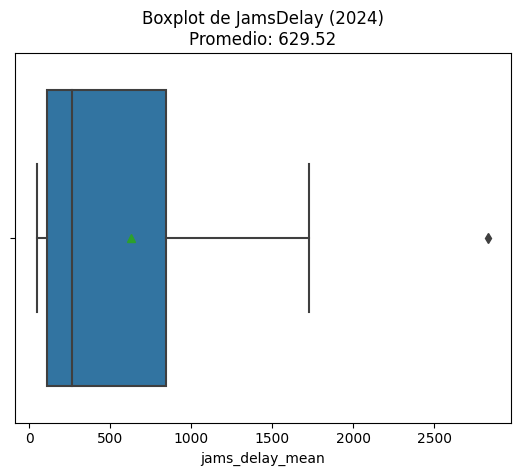

In [83]:

# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
import seaborn as sns
import matplotlib.pyplot as plt

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay_mean'].mean()
sns.boxplot(data=merged,x='jams_delay_mean',showmeans=True)
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()



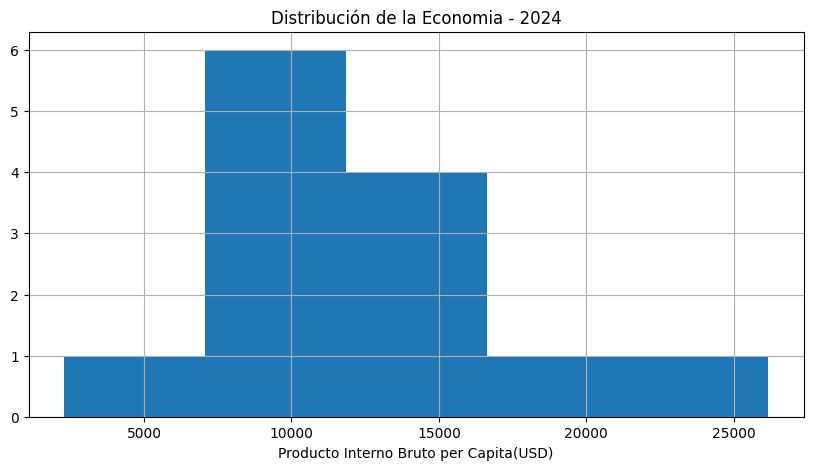

In [84]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
eco_2024_small['city_gdp_capita'].hist(bins=5,figsize=(10,5))
plt.title('Distribución de la Economia - 2024')
plt.xlabel('Producto Interno Bruto per Capita(USD)')
plt.show()



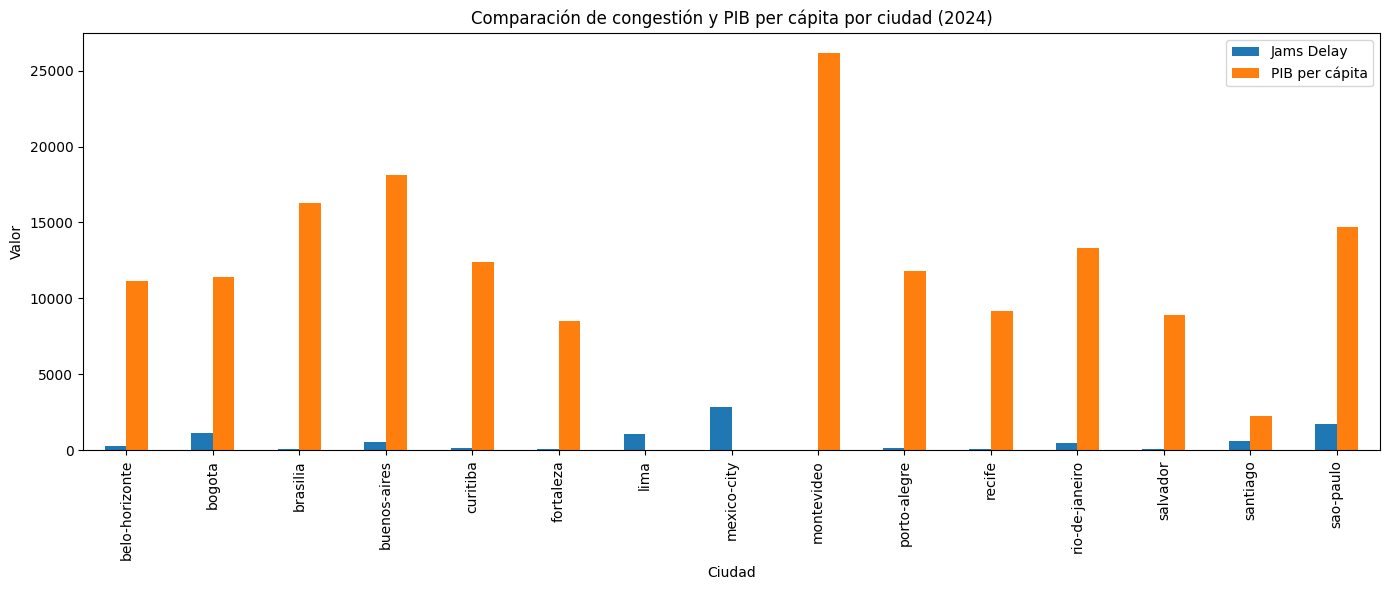

In [85]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])
merged.plot(
    x='city',
    y=['jams_delay_mean', 'city_gdp_capita'],
    kind='bar',
    figsize=(14, 6)
)

plt.title('Comparación de congestión y PIB per cápita por ciudad (2024)')
plt.xlabel('Ciudad')
plt.ylabel('Valor')
plt.xticks(rotation=90)
plt.legend(['Jams Delay', 'PIB per cápita'])
plt.tight_layout()


plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: No se observa una relación directa entre el PIB per cápita y la congestión. Aunque algunas ciudades con PIB per cápita elevado presentan niveles importantes de JamsDelay, también existen ciudades con PIB más bajo que registran congestión alta. Por lo tanto, un mayor nivel económico no implica necesariamente una mayor congestión; otros factores como el tamaño de la población, infraestructura vial y volumen de tráfico pueden influir.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [27]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?


In [88]:
analisis = """
RESUMEN EJECUTIVO — Movilidad Urbana y Productividad Económica en LATAM (2024)

CONTEXTO Y OBJETIVO
El análisis busca responder si existe una relación entre la congestión vehicular 
(medida a través de jams_delay_mean, tiempos de viaje y densidad de tráfico) y la 
productividad económica (city_gdp_capita) en ciudades de América Latina.Esta relación es relevante porque permite identificar si la infraestructura de transporte deficiente está asociada a menor desarrollo económico urbano, lo cual orienta decisiones de inversión pública

COBERTURA DE DATOS
El panel final incluye 14 ciudades de 7 países latinoamericanos (Argentina, Brasil, Chile, Colombia, México, Perú y Uruguay) para el año 2024: Belo Horizonte, Bogotá, Brasilia, Buenos Aires, Curitiba, Fortaleza, Lima, Ciudad de México, Montevideo, Porto Alegre, Recife, Río de Janeiro, Salvador, Santiago y São Paulo.

METODOLOGÍA (ALTO NIVEL)
Se estandarizaron los nombres de país en ambas tablas (traducción inglés→español y corrección de tildes) para poder aplicar .isin() sin pérdida de filas. Los datos de tráfico se agregaron por ciudad-año (jams_delay_mean, tiempos de viaje históricos y en vivo) y se integraron con la tabla de economía mediante un LEFT JOIN por ciudad y año. Se validó la distribución de ambas variables con un boxplot (JamsDelay) y un histograma (PIB per cápita) antes de cruzar los datos, para detectar outliers previamente al análisis de correlación.

HALLAZGOS INICIALES
El promedio de retraso por congestión en el subconjunto LATAM (629.52)es considerablemente más alto que el del panel global completo (178.14), confirmando que la región concentra niveles de congestión por encima del promedio mundial. Visualmente, se observa un patrón consistente con una relación negativa: ciudades con congestión alta (Ciudad de México, Bogotá, São Paulo) tienden a ubicarse en la mitad baja de PIB per cápita, mientras que ciudades con congestión mínima (Montevideo, Brasilia) están entre las de mayor PIB per cápita del panel. Sin embargo, hay dos anomalías que deben validarse antes de sacar conclusiones firmes: Lima y Ciudad de México muestran una barra de PIB per cápita prácticamente en cero en el gráfico — sugiere un dato faltante o un error de unión/formato, no un valor real. Santiago, por su parte, reporta un PIB per cápita de apenas ~2,200 USD, una cifra muy por debajo de lo esperado para Chile, lo que apunta a un error de captura o de escala (posiblemente en miles vs. unidades).

RECOMENDACIONES
Con los datos válidos disponibles, Bogotá es la ciudad que mejor cumple el perfil de "alta congestión + baja productividad relativa": tiene el segundo nivel de congestión más alto del panel (1,141 min de retraso promedio) y uno de los PIB per cápita más bajos (11,442 USD, por debajo de la mediana del grupo). A diferencia de Lima y Ciudad de México — que podrían ser candidatas aún más fuertes pero cuyo dato de PIB parece corrupto —, Bogotá tiene ambas variables completas y confiables, lo que la convierte en la recomendación más sólida para priorizar inversión en infraestructura de transporte. 
"""

print(analisis)


RESUMEN EJECUTIVO — Movilidad Urbana y Productividad Económica en LATAM (2024)

CONTEXTO Y OBJETIVO
El análisis busca responder si existe una relación entre la congestión vehicular 
(medida a través de jams_delay_mean, tiempos de viaje y densidad de tráfico) y la 
productividad económica (city_gdp_capita) en ciudades de América Latina.Esta relación es relevante porque permite identificar si la infraestructura de transporte deficiente está asociada a menor desarrollo económico urbano, lo cual orienta decisiones de inversión pública

COBERTURA DE DATOS
El panel final incluye 14 ciudades de 7 países latinoamericanos (Argentina, Brasil, Chile, Colombia, México, Perú y Uruguay) para el año 2024: Belo Horizonte, Bogotá, Brasilia, Buenos Aires, Curitiba, Fortaleza, Lima, Ciudad de México, Montevideo, Porto Alegre, Recife, Río de Janeiro, Salvador, Santiago y São Paulo.

METODOLOGÍA (ALTO NIVEL)
Se estandarizaron los nombres de país en ambas tablas (traducción inglés→español y corrección de t